# 🚀 AIC 2026 — End-to-End Pipeline


### Pipeline 6 bước
1. Giải nén dữ liệu BTC
2. Tạo Metadata & Trích xuất Transcript âm thanh (Whisper)
3. **Huấn luyện LoRA CLIP** (GPU AMD — batch=4, accum=8)
4. **Trích xuất Feature Vectors** (GPU AMD DirectML — inference siêu nhanh)
5. Đẩy Vectors lên Qdrant Vector Database
6. Thử nghiệm tìm kiếm

## 📦 Bước 0: Cài đặt thư viện

In [ ]:
!pip install -r requirements.txt

In [ ]:
# Kiểm tra GPU AMD DirectML
import torch
import torch_directml

print(f"PyTorch: {torch.__version__}")
print(f"DirectML available: {torch_directml.is_available()}")
print(f"GPU device: {torch_directml.device()}")
print(f"GPU name: {torch_directml.device_name(0)}")

## 📂 Bước 1: Giải nén dữ liệu BTC
Tự động giải nén các file `.zip` trong `ZIP/` vào đúng cấu trúc `data/`.

In [ ]:
# Xem trước các file sẽ giải nén
!python scripts/extract_btc_data.py --dry-run

In [ ]:
# Giải nén thực tế
!python scripts/extract_btc_data.py

## 📄 Bước 2: Import Metadata & Transcript
Quét keyframes, map frame_id, tích hợp lời thoại âm thanh từ Whisper vào `data/index/metadata.jsonl`.

In [ ]:
!python scripts/import_btc_data.py --with-transcript

## 🧠 Bước 3: Huấn luyện LoRA Fine-Tuning cho CLIP

Fine-tune CLIP ViT-B/32 bằng LoRA adapters (~0.28% tham số, ~1.7MB).

### 🖥️ Chạy trên GPU AMD DirectML
- **batch-size = 4** (vừa VRAM 4GB của AMD Radeon RX 5500M)
- **accum-steps = 8** (Gradient Accumulation → effective batch = 4 × 8 = 32)
- **Yêu cầu:** Đã tăng Windows TDR Timeout lên 60s và **restart máy**

### Thông số
| Thông số | Giá trị | Ý nghĩa |
|---|---|---|
| `--epochs 3` | 3 vòng | 66,744 lượt keyframe |
| `--batch-size 4` | 4 ảnh/lần | Vừa VRAM 4GB GPU AMD |
| `--accum-steps 8` | Tích lũy 8 bước | Effective batch = 32 |

### ⚠️ Nếu GPU bị crash (TDR reset)
Chạy lệnh sau trong PowerShell (Admin) rồi **restart máy**:
```powershell
reg add \"HKLM\\SYSTEM\\CurrentControlSet\\Control\\GraphicsDrivers\" /v TdrDelay /t REG_DWORD /d 60 /f
```
Hoặc fallback CPU: `--batch-size 32 --accum-steps 1 --device cpu`

In [ ]:
# Huấn luyện LoRA CLIP trên GPU AMD DirectML
# (Cần restart máy sau khi tăng TDR Timeout)
!python scripts/train_lora_clip.py --epochs 3 --batch-size 4 --accum-steps 8

In [ ]:
# [TÙY CHỌN] Học tiếp từ checkpoint cũ
# !python scripts/train_lora_clip.py --epochs 3 --batch-size 4 --accum-steps 8 --resume

In [ ]:
# [FALLBACK] Nếu GPU vẫn crash → chạy trên CPU
# !python scripts/train_lora_clip.py --device cpu --epochs 3 --batch-size 32

## 🎨 Bước 4: Trích xuất Feature Vectors bằng LoRA-CLIP

Chiết xuất vector đặc trưng 512d cho toàn bộ keyframes bằng model đã fine-tune.

### ✅ Bước này chạy trên GPU AMD DirectML (siêu nhanh)
- Forward-only inference, không cần backward pass
- GPU AMD Radeon RX 5500M xử lý batch 128 ảnh cùng lúc
- Có cơ chế skip: keyframe đã extract sẽ bị bỏ qua

### ⚠️ Nếu đã extract từ trước khi train LoRA
Cần **xóa clip-features cũ** rồi extract lại để dùng mô hình mới.

In [ ]:
# [TÙY CHỌN] Xóa clip-features cũ nếu vừa train LoRA xong
import shutil
from pathlib import Path

clip_features_dir = Path("data/clip-features")
if clip_features_dir.exists():
    count = sum(1 for _ in clip_features_dir.rglob("*.npy"))
    print(f"Tìm thấy {count} file .npy cũ trong data/clip-features/")
    confirm = input("Xóa toàn bộ để extract lại? (y/n): ")
    if confirm.lower() == 'y':
        shutil.rmtree(clip_features_dir)
        clip_features_dir.mkdir(parents=True, exist_ok=True)
        print("Đã xóa. Sẵn sàng extract lại.")
    else:
        print("Giữ nguyên. Script sẽ skip các file đã tồn tại.")

In [ ]:
# Trích xuất CLIP features trên GPU AMD DirectML
!python scripts/extract_clip_features.py

## 🚀 Bước 5: Đẩy Vectors lên Qdrant Vector Database
Lưu trữ vector và payload metadata lên Qdrant Remote/Local để tìm kiếm similarity.

In [ ]:
!python backend/embedding/push_to_remote.py --recreate

## 🔍 Bước 6: Thử nghiệm Tìm kiếm
Kiểm tra tìm kiếm câu truy vấn mẫu.

In [2]:
from backend.embedding.clip_encoder import encode_text_raw
import numpy as np

query = "a photo of a tree"
vec = encode_text_raw(query)
print(f"Query: '{query}' -> Vector shape: {vec.shape}, norm: {np.linalg.norm(vec):.4f}")

Query: 'a photo of a tree' -> Vector shape: (512,), norm: 1.0000


In [3]:
# Tìm kiếm trên Qdrant
from qdrant_client import QdrantClient
from backend.config import QDRANT_URL, QDRANT_API_KEY, QDRANT_COLLECTION_NAME

client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

response = client.query_points(
    collection_name=QDRANT_COLLECTION_NAME,
    query=vec.tolist(),
    limit=10,
)

print(f"\n🔍 Top 10 kết quả cho: '{query}'\n")
for i, hit in enumerate(response.points, 1):
    p = hit.payload
    print(f"  #{i:02d} | Score: {hit.score:.4f} | {p.get('video_id','')} | Frame: {p.get('frame_id','')} | {p.get('pts_time',0):.1f}s")



🔍 Top 10 kết quả cho: 'a photo of a tree'

  #01 | Score: 0.2463 | L21_V001 | Frame: 2820 | 94.0s
  #02 | Score: 0.2413 | L21_V001 | Frame: 4836 | 161.2s
  #03 | Score: 0.2386 | L21_V001 | Frame: 3408 | 113.6s
  #04 | Score: 0.2384 | L21_V001 | Frame: 28428 | 947.6s
  #05 | Score: 0.2382 | L21_V001 | Frame: 28296 | 943.2s
  #06 | Score: 0.2373 | L21_V001 | Frame: 22104 | 736.8s
  #07 | Score: 0.2373 | L21_V001 | Frame: 12534 | 417.8s
  #08 | Score: 0.2372 | L21_V001 | Frame: 2820 | 94.0s
  #09 | Score: 0.2357 | L21_V001 | Frame: 28224 | 940.8s
  #10 | Score: 0.2320 | L21_V001 | Frame: 3678 | 122.6s


Matplotlib is building the font cache; this may take a moment.


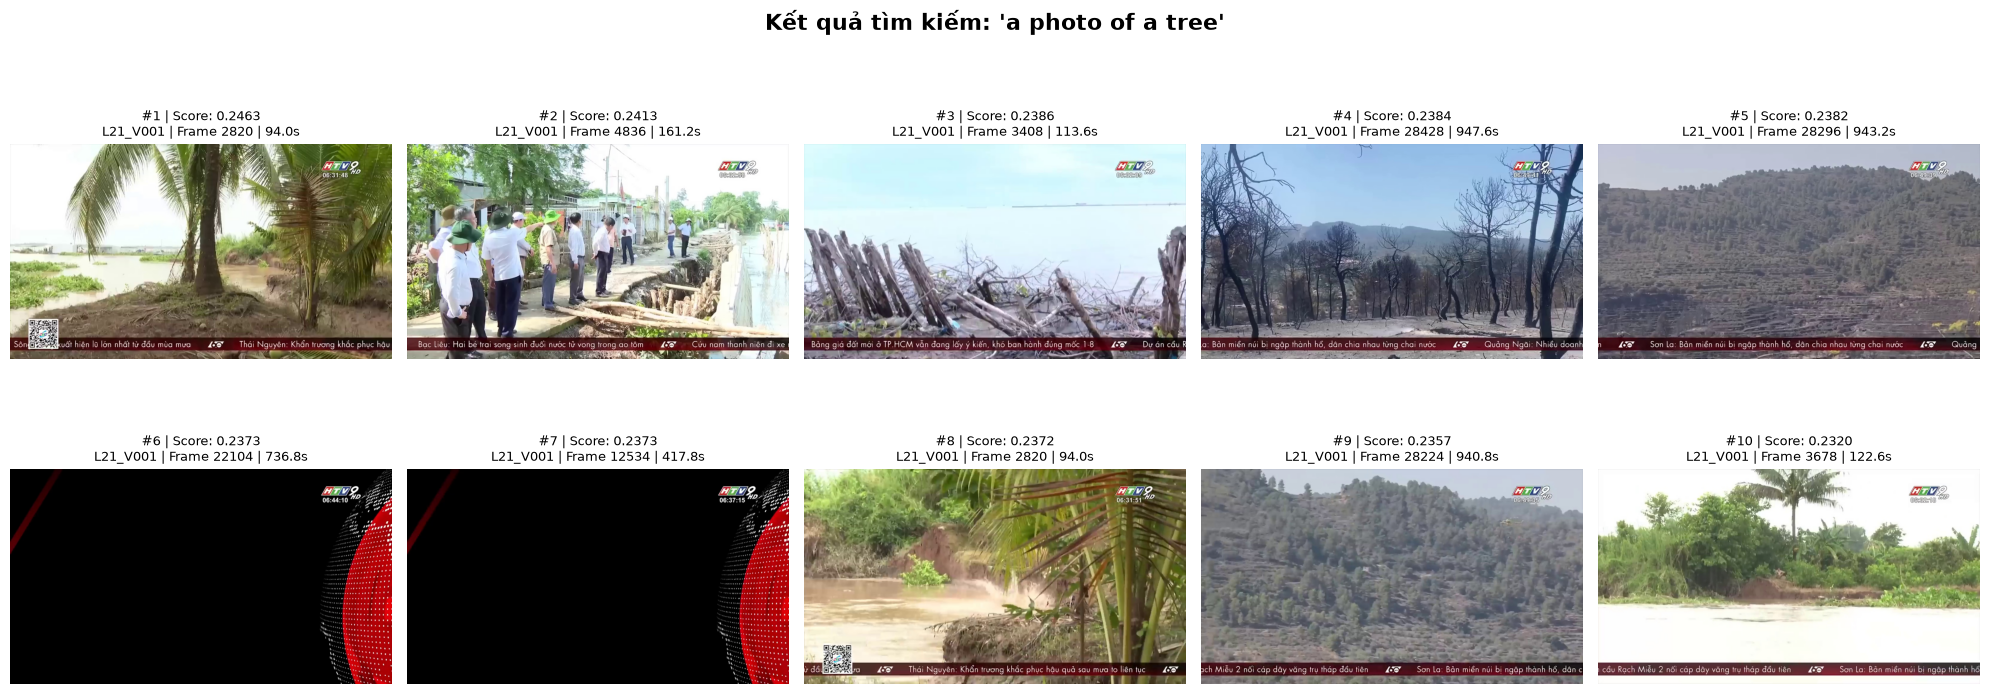

In [4]:
# Hiển thị ảnh keyframe từ kết quả tìm kiếm
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

hits = response.points
n = min(len(hits), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f"Kết quả tìm kiếm: '{query}'", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n:
        hit = hits[i]
        p = hit.payload
        img_path = Path(p.get('path', ''))
        vid = p.get('video_id', '')
        fid = p.get('frame_id', 0)
        pts = p.get('pts_time', 0.0)
        score = hit.score

        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', transform=ax.transAxes)

        ax.set_title(f'#{i+1} | Score: {score:.4f}\n{vid} | Frame {fid} | {pts:.1f}s', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
